# Chapter 3, Example 2: Exact Sum-Product Message Passing on a Tree

On a tree, variable elimination can be organized so that no fill-in is created. Local summaries move from leaves toward a chosen root and then back toward the leaves. These summaries are the messages of the sum-product or belief-propagation algorithm.

This notebook demonstrates:

- exact messages on a binary pairwise tree;
- a two-pass schedule;
- exact singleton marginals and the partition function;
- agreement with brute-force enumeration;
- the meaning of a message as a partial partition function.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name == "ch03":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch03").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch03"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

NODE_COLOR = "#2F6B9A"
FACTOR_COLOR = "#555555"

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## 1. Model

For spins $s_i\in\{-1,+1\}$ on a tree,

$$
p(\boldsymbol{s})=\frac{1}{Z}\prod_i e^{h_i s_i}\prod_{(i,j)\in E}e^{J_{ij}s_is_j}.
$$

Removing an edge splits a tree into two components. A message from $i$ to $j$ sums the component on the $i$ side while keeping $s_j$ fixed.

Saved: figs/ch03_02_tree_model.pdf


Saved: figs/ch03_02_tree_model.png


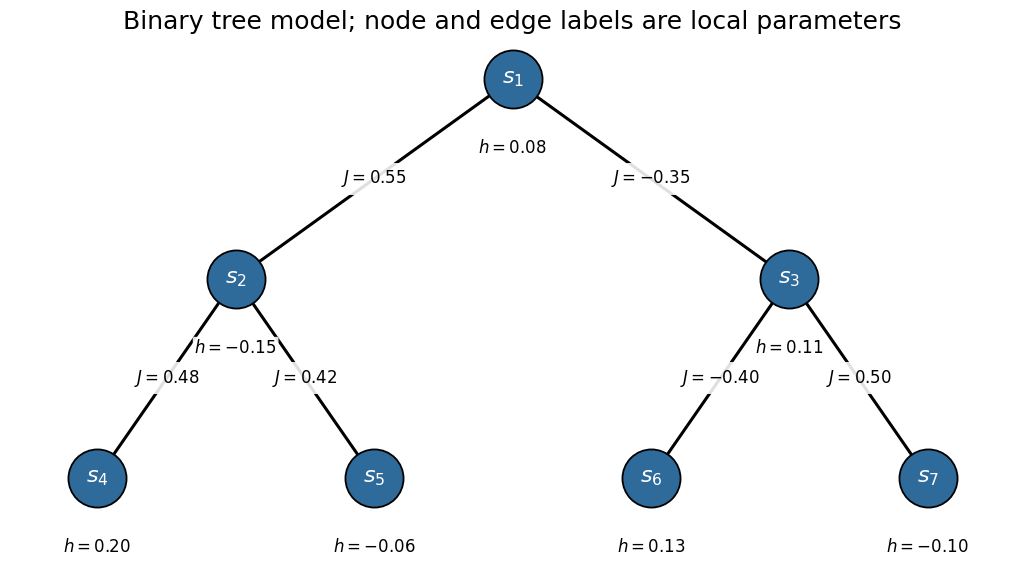

In [2]:
nodes=list(range(7))
edges=[(0,1),(0,2),(1,3),(1,4),(2,5),(2,6)]
pos={0:(0,2),1:(-1.8,1),2:(1.8,1),3:(-2.7,0),4:(-0.9,0),5:(0.9,0),6:(2.7,0)}
h=np.array([0.08,-0.15,0.11,0.20,-0.06,0.13,-0.10])
J={tuple(sorted(e)):v for e,v in zip(edges,[0.55,-0.35,0.48,0.42,-0.40,0.50])}

def spin(b): return 2*b-1
def unary(i,b): return np.exp(h[i]*spin(b))
def pair(i,j,bi,bj): return np.exp(J[tuple(sorted((i,j)))]*spin(bi)*spin(bj))
neighbors={i:[] for i in nodes}
for i,j in edges: neighbors[i].append(j); neighbors[j].append(i)

fig,ax=plt.subplots(figsize=(10.5,5.9))
g=nx.Graph(edges)
nx.draw_networkx_edges(g,pos,width=2.2,ax=ax)
nx.draw_networkx_nodes(g,pos,node_size=1750,node_color=NODE_COLOR,edgecolors="black",linewidths=1.3,ax=ax)
node_labels={i:rf"$s_{{{i+1}}}$" for i in nodes}
nx.draw_networkx_labels(g,pos,labels=node_labels,font_size=16,font_color="white",ax=ax)
for i,(x,y) in pos.items():
    ax.text(x, y-0.30, rf"$h={h[i]:.2f}$", ha="center", va="top", fontsize=12,
            bbox={"boxstyle":"round,pad=0.10","facecolor":"white","edgecolor":"none","alpha":0.88})
edge_labels={e:rf"$J={J[tuple(sorted(e))]:.2f}$" for e in edges}
nx.draw_networkx_edge_labels(g,pos,edge_labels=edge_labels,font_size=12,rotate=False,bbox={"facecolor":"white","edgecolor":"none","alpha":0.88},ax=ax)
ax.set_title("Binary tree model; node and edge labels are local parameters")
ax.axis("off"); fig.tight_layout(); save_figure(fig,"ch03_02_tree_model"); plt.show()

## 2. Messages

For a directed edge $i\to j$, define

$$
m_{i\to j}(s_j)=\sum_{s_i}e^{h_i s_i}e^{J_{ij}s_is_j}\prod_{k\in\partial i\setminus j}m_{k\to i}(s_i).
$$

The product contains all information entering $i$ from the component away from $j$. Messages can be normalized without changing the final marginals; here we normalize them to sum to one for numerical readability.

In [3]:
messages={}
message_order=[]

def compute_message(i,j):
    key=(i,j)
    if key in messages: return messages[key]
    incoming=[compute_message(k,i) for k in neighbors[i] if k!=j]
    msg=np.zeros(2)
    for bj in (0,1):
        for bi in (0,1):
            value=unary(i,bi)*pair(i,j,bi,bj)
            for arr in incoming: value*=arr[bi]
            msg[bj]+=value
    msg/=msg.sum()
    messages[key]=msg; message_order.append(key)
    return msg

for i,j in edges:
    compute_message(i,j); compute_message(j,i)

message_table=pd.DataFrame([{"message":f"{i+1}->{j+1}","m(-1)":m[0],"m(+1)":m[1]} for (i,j),m in messages.items()])
display(message_table.sort_values("message").reset_index(drop=True))

,message,m(-1),m(+1)
0,1->2,0.481256,0.518744
1,1->3,0.506269,0.493731
2,2->1,0.521342,0.478658
3,2->4,0.530222,0.469778
4,2->5,0.504800,0.495200
5,3->1,0.502481,0.497519
6,3->6,0.509751,0.490249
7,3->7,0.488847,0.511153
8,4->2,0.455961,0.544039
9,5->2,0.511894,0.488106


## 3. Marginals and partition function

Once both directed messages on every edge are available, the singleton marginal is

$$
b_i(s_i)\propto e^{h_i s_i}\prod_{k\in\partial i}m_{k\to i}(s_i).
$$

To compute $Z$, choose any root and combine all incoming unnormalized partial partition functions at that root. The choice of root changes the schedule but not the answer.

In [4]:
def exact_distribution():
    states=np.array(list(product((0,1),repeat=len(nodes))),dtype=int)
    weights=[]
    for bits in states:
        expo=sum(h[i]*spin(bits[i]) for i in nodes)+sum(J[tuple(sorted((i,j)))]*spin(bits[i])*spin(bits[j]) for i,j in edges)
        weights.append(np.exp(expo))
    weights=np.array(weights); return states,weights/weights.sum(),weights.sum()

states,p_exact,Z_exact=exact_distribution()
exact_plus=np.array([p_exact[states[:,i]==1].sum() for i in nodes])

bp_plus=[]
for i in nodes:
    belief=np.array([unary(i,b) for b in (0,1)],dtype=float)
    for k in neighbors[i]: belief*=messages[(k,i)]
    belief/=belief.sum(); bp_plus.append(belief[1])
bp_plus=np.array(bp_plus)

# Compute Z with unnormalized recursive messages directed to root 0.
def raw_message(i,j,parent):
    msg=np.zeros(2)
    for bj in (0,1):
        for bi in (0,1):
            val=unary(i,bi)*pair(i,j,bi,bj)
            for k in neighbors[i]:
                if k!=j: val*=raw_message(k,i,i)[bi]
            msg[bj]+=val
    return msg
root=0
root_weight=np.array([unary(root,b) for b in (0,1)],dtype=float)
for k in neighbors[root]: root_weight*=raw_message(k,root,root)
Z_bp=root_weight.sum()

comparison=pd.DataFrame({"variable":[f"s{i+1}" for i in nodes],"exact P(+1)":exact_plus,"BP P(+1)":bp_plus,"absolute error":abs(exact_plus-bp_plus)})
display(comparison)
print(f"Exact Z = {Z_exact:.12f}")
print(f"BP/tree-DP Z = {Z_bp:.12f}")
assert np.max(abs(exact_plus-bp_plus))<1e-12
assert abs(Z_exact-Z_bp)/Z_exact<1e-12

,variable,exact P(+1),BP P(+1),absolute error
0,s1,0.516159,0.516159,0.000000e+00
1,s2,0.476028,0.476028,0.000000e+00
2,s3,0.501107,0.501107,1.110223e-16
3,s4,0.569293,0.569293,1.110223e-16
4,s5,0.465256,0.465256,5.551115e-17
5,s6,0.555024,0.555024,1.110223e-16
6,s7,0.461232,0.461232,1.110223e-16


Exact Z = 240.585036870469
BP/tree-DP Z = 240.585036870469


Saved: figs/ch03_02_tree_marginal_comparison.pdf


Saved: figs/ch03_02_tree_marginal_comparison.png


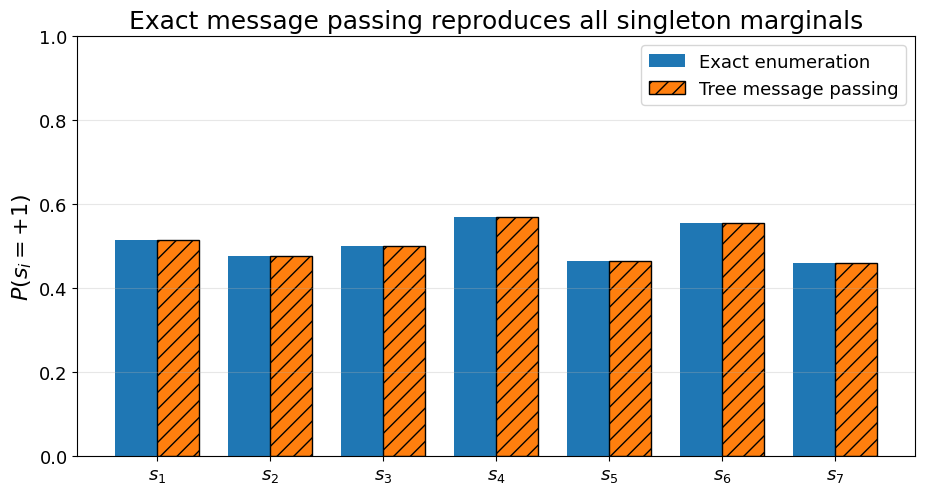

Saved: figs/ch03_02_directed_messages.pdf
Saved: figs/ch03_02_directed_messages.png


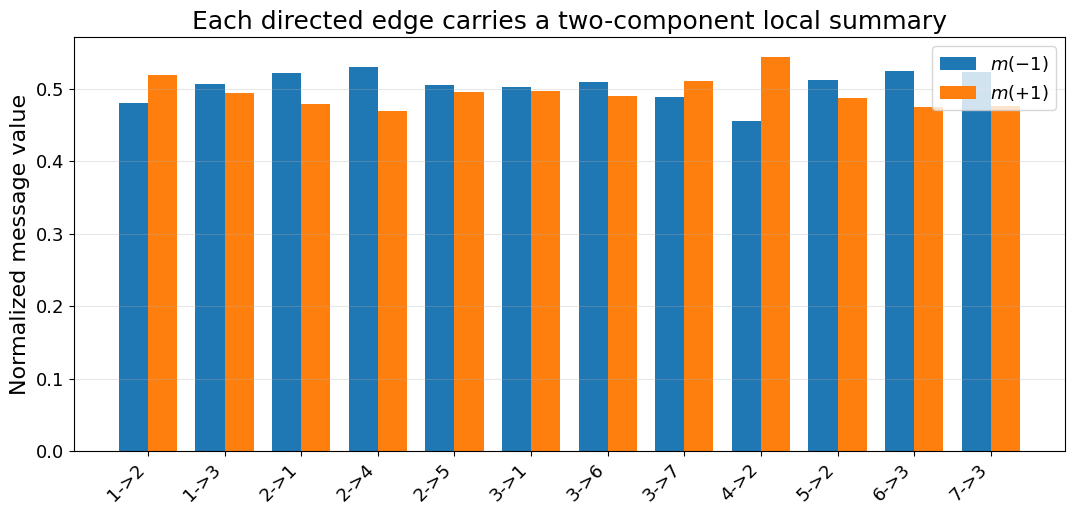

In [5]:
fig,ax=plt.subplots(figsize=(9.5,5.2))
x=np.arange(len(nodes)); width=0.37
ax.bar(x-width/2,exact_plus,width,label="Exact enumeration")
ax.bar(x+width/2,bp_plus,width,label="Tree message passing",hatch="//",edgecolor="black")
ax.set_xticks(x,[rf"$s_{{{i+1}}}$" for i in nodes])
ax.set_ylim(0,1); ax.set_ylabel(r"$P(s_i=+1)$")
ax.set_title("Exact message passing reproduces all singleton marginals")
ax.grid(axis="y",alpha=0.3); ax.legend()
fig.tight_layout(); save_figure(fig,"ch03_02_tree_marginal_comparison"); plt.show()

ordered=message_table.sort_values("message")
fig,ax=plt.subplots(figsize=(11,5.4))
x=np.arange(len(ordered)); width=0.38
ax.bar(x-width/2,ordered["m(-1)"],width,label=r"$m(-1)$")
ax.bar(x+width/2,ordered["m(+1)"],width,label=r"$m(+1)$")
ax.set_xticks(x,ordered["message"],rotation=45,ha="right")
ax.set_ylabel("Normalized message value")
ax.set_title("Each directed edge carries a two-component local summary")
ax.grid(axis="y",alpha=0.3); ax.legend()
fig.tight_layout(); save_figure(fig,"ch03_02_directed_messages"); plt.show()

## 4. Why trees are special

Every message summarizes a disjoint subtree. No information returns through a second route, so the local summaries are exact and a finite two-pass schedule suffices. On a graph with loops, the same update equations can be iterated, but the incoming messages are no longer summaries of disjoint components. Their use then becomes an approximation.

## Exercises

1. Change the root used to compute $Z$ and verify that the answer is unchanged.
2. Reverse the sign of one edge coupling and explain the resulting marginal changes.
3. Replace summation by maximization and implement max-product messages for the MAP state.
4. Compute pairwise edge marginals from the two directed messages and compare them with enumeration.
5. Add one edge to create a loop. Run the same updates iteratively and compare with exact enumeration.